# **Prediksi Risiko Burnout Mahasiswa Berdasarkan Penggunaan GenAI dan Pola Belajar**

## **1. Business Understanding**

### **1.1 Latar Belakang**
Penggunaan GenAI di kalangan mahasiswa semakin meningkat untuk membantu aktivitas belajar, seperti mencari ide, merangkum materi, menulis, hingga menyelesaikan permasalahan akademik. Namun, penggunaan yang tidak seimbang dapat berpotensi menimbulkan ketergantungan, kecemasan saat ujian, penurunan pola belajar mandiri, dan risiko burnout.


### **1.2 Problem Statement**
Bagaimana membangun model machine learning yang mampu memprediksi tingkat risiko burnout mahasiswa berdasarkan pola penggunaan GenAI, kebiasaan belajar, kondisi akademik, dan faktor psikologis?

### **1.3 Tujuan**
Proyek ini bertujuan untuk:
- Menganalisis karakteristik data mahasiswa terkait penggunaan GenAI.
- Menemukan pola yang berhubungan dengan risiko burnout.
- Membangun model klasifikasi untuk memprediksi tingkat risiko burnout.
- Mengembangkan aplikasi prediksi berbasis Streamlit.


## **2. Data Understanding**

### **2.1 Import Library**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import joblib

### **Sumber Dataset**
Nama dataset : AI Student Impact Dataset

Sumber : https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students


### **2.2 Load Dataset**

In [3]:
df = pd.read_csv("ai_student_impact_dataset (1).csv")

print("5 data teratas :")
df.head()

5 data teratas :


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


### **2.3 Data Identification**
Identifikasi data dilakukan untuk mengetahui jumlah baris, jumlah kolom, nama variabel, tipe data, dan statistik deskriptif dari setiap variabel.

In [4]:
print("Jumlah baris dan kolom:", df.shape)

print("\nNama Kolom: ")
print(df.columns)

print("\nInformasi data: ")
df.info()

print("\nStatistika Deskriptif")
df.describe()

Jumlah baris dan kolom: (50000, 16)

Nama Kolom: 
Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='str')

Informasi data: 
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Ca

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


### **2.4 Penjelasan Variabel**

In [5]:
variable_info = pd.DataFrame({
    "Nama Kolom": df.columns,
    "Tipe Data": df.dtypes.values,
})

variable_info

,Nama Kolom,Tipe Data
0,Student_ID,int64
1,Major_Category,str
2,Year_of_Study,str
3,Pre_Semester_GPA,float64
4,Weekly_GenAI_Hours,float64
5,Primary_Use_Case,str
6,Prompt_Engineering_Skill,str
7,Tool_Diversity,int64
8,Paid_Subscription,bool
9,Traditional_Study_Hours,float64


### **2.5 Distribusi Target**
Variabel `Burnout_Risk_Level` digunakan sebagai target prediksi. Pemeriksaan distribusi target dilakukan untuk mengetahui jumlah mahasiswa pada setiap kategori risiko burnout.

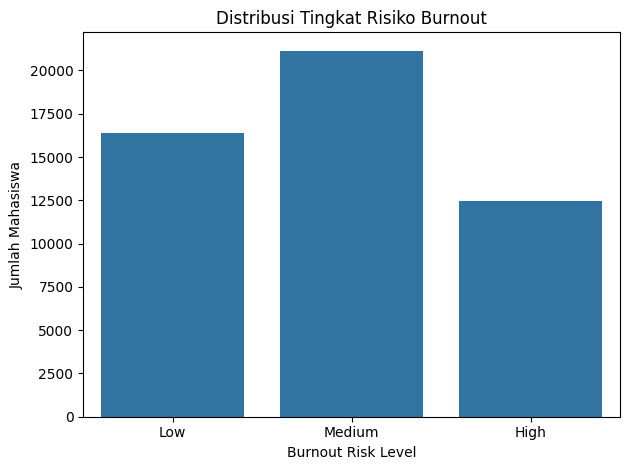

In [6]:
df["Burnout_Risk_Level"].value_counts()

sns.countplot(
    data=df,
    x="Burnout_Risk_Level",
    order=["Low", "Medium", "High"]
)

plt.title("Distribusi Tingkat Risiko Burnout")
plt.xlabel("Burnout Risk Level")
plt.ylabel("Jumlah Mahasiswa")
plt.tight_layout()
plt.show()

## **3. Exploratory Data Analysis**
EDA dilakukan untuk memahami pola dan hubungan antara penggunaan GenAI, ketergantungan terhadap AI, kecemasan saat ujian, serta tingkat risiko burnout mahasiswa.

### **3.1 Hubungan Weekly GenAI Hours dengan Burnout Risk**

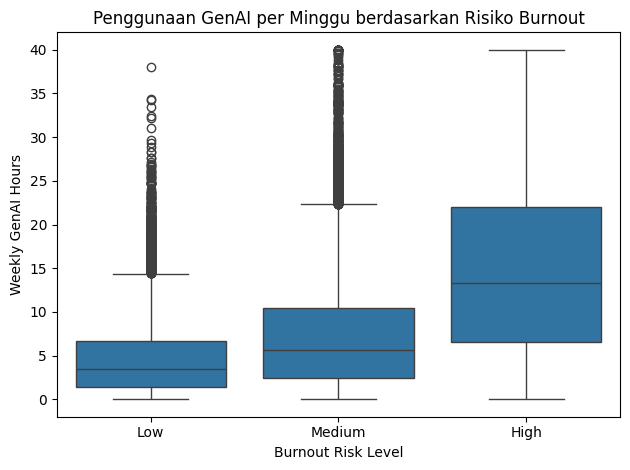

In [7]:
sns.boxplot(
    data=df,
    x="Burnout_Risk_Level",
    y="Weekly_GenAI_Hours",
    order=["Low", "Medium", "High"]
)

plt.title("Penggunaan GenAI per Minggu berdasarkan Risiko Burnout")
plt.xlabel("Burnout Risk Level")
plt.ylabel("Weekly GenAI Hours")
plt.tight_layout()
plt.show()

Boxplot menunjukkan adanya kecenderungan peningkatan durasi penggunaan GenAI seiring meningkatnya tingkat risiko burnout.

- Kelompok Low memiliki median penggunaan GenAI sekitar 3–4 jam per minggu.
- Kelompok Medium memiliki median sekitar 5–6 jam per minggu.
- Kelompok High memiliki median paling tinggi, yaitu sekitar 13 jam per minggu.
- Kelompok High juga mempunyai rentang penggunaan yang lebih luas. Hal ini menunjukkan bahwa durasi penggunaan GenAI pada kelompok tersebut lebih bervariasi.
- Titik-titik di luar garis boxplot pada kelompok Low dan Medium merupakan **outlier**, yaitu mahasiswa dengan penggunaan GenAI jauh lebih tinggi dibandingkan mayoritas mahasiswa pada kelompok yang sama.

Berdasarkan visualisasi tersebut, mahasiswa dengan risiko burnout yang lebih tinggi cenderung menggunakan GenAI lebih lama setiap minggunya. Namun, hasil ini hanya menunjukkan hubungan atau pola pada dataset dan tidak membuktikan bahwa penggunaan GenAI secara langsung menyebabkan burnout.

### **3.2 Hubungan Perceived AI Dependency dengan Burnout Risk**

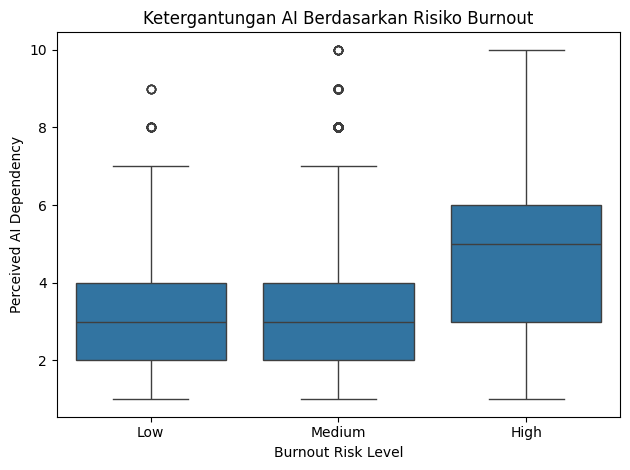

In [8]:
sns.boxplot(
    data=df,
    x="Burnout_Risk_Level",
    y="Perceived_AI_Dependency",
    order=["Low", "Medium", "High"]
)

plt.title("Ketergantungan AI Berdasarkan Risiko Burnout")
plt.xlabel("Burnout Risk Level")
plt.ylabel("Perceived AI Dependency")
plt.tight_layout()
plt.show()

Boxplot membandingkan tingkat ketergantungan mahasiswa terhadap AI pada skala 1–10 untuk setiap kategori risiko burnout.

- Kelompok Low memiliki median ketergantungan AI sekitar 3.
- Kelompok Medium juga memiliki median sekitar 3 dan distribusinya banyak bertumpang tindih dengan kelompok Low.
- Kelompok High memiliki median lebih tinggi, yaitu sekitar 5, dengan sebagian besar nilai berada pada rentang 3–6.
- Terdapat beberapa outlier pada kelompok Low dan Medium dengan tingkat ketergantungan mencapai 8–10.
- Kelompok High memiliki rentang nilai yang lebih luas, dari sekitar 1 hingga 10.

Visualisasi ini menunjukkan bahwa mahasiswa dengan risiko burnout tinggi cenderung memiliki tingkat ketergantungan terhadap AI yang lebih tinggi. Namun, kemiripan distribusi kelompok Low dan Medium menunjukkan bahwa ketergantungan AI saja belum cukup untuk membedakan tingkat risiko burnout.

Oleh karena itu, prediksi burnout perlu mempertimbangkan variabel lain, seperti durasi penggunaan GenAI, jam belajar tradisional, dan tingkat kecemasan saat ujian. Hasil ini menunjukkan keterkaitan, bukan hubungan sebab-akibat.

### **3.3 Hubungan Anxiety Level During Exams dengan Burnout Risk**

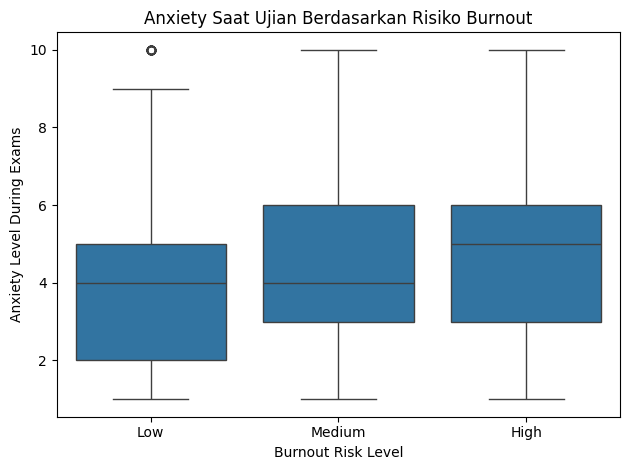

In [9]:
sns.boxplot(
    data=df,
    x="Burnout_Risk_Level",
    y="Anxiety_Level_During_Exams",
    order=["Low", "Medium", "High"]
)

plt.title("Anxiety Saat Ujian Berdasarkan Risiko Burnout")
plt.xlabel("Burnout Risk Level")
plt.ylabel("Anxiety Level During Exams")
plt.tight_layout()
plt.show()

Boxplot membandingkan tingkat kecemasan mahasiswa saat ujian pada skala 1–10 berdasarkan kategori risiko burnout.

- Kelompok Low memiliki median kecemasan sekitar 4, dengan sebagian besar nilai berada pada rentang 2–5.
- Kelompok Medium memiliki median sekitar 4, dengan sebagian besar nilai berada pada rentang 3–6.
- Kelompok High memiliki median paling tinggi, yaitu sekitar 5, dengan sebagian besar nilai berada pada rentang 3–6.
- Distribusi ketiga kelompok cukup banyak bertumpang tindih. Artinya, mahasiswa dari setiap kategori burnout dapat memiliki tingkat kecemasan yang serupa.
- Terdapat beberapa mahasiswa pada kelompok Low dengan kecemasan sangat tinggi, tetapi nilai tersebut merupakan outlier dan tidak mewakili mayoritas kelompok.

Visualisasi menunjukkan bahwa kelompok dengan risiko burnout tinggi cenderung memiliki tingkat kecemasan saat ujian yang lebih tinggi. Namun, perbedaannya tidak terlalu besar dan distribusi antarkelompok masih banyak bertumpang tindih.

Oleh karena itu, kecemasan saat ujian dapat membantu proses prediksi, tetapi tidak cukup digunakan sebagai satu-satunya indikator risiko burnout.

### **3.4 Ringkasan Rata-Rata Berdasarkan Risiko Burnout**
Perhitungan rata-rata dilakukan untuk membandingkan penggunaan GenAI, ketergantungan AI, dan kecemasan saat ujian pada setiap kategori risiko burnout.

In [30]:
eda_summary = (
    df.groupby("Burnout_Risk_Level")[
        [
            "Weekly_GenAI_Hours",
            "Perceived_AI_Dependency",
            "Anxiety_Level_During_Exams",
        ]
    ]
    .mean()
    .reindex(["Low", "Medium", "High"])
    .round(2)
)

eda_summary

,Weekly_GenAI_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams
Burnout_Risk_Level,,,
Low,4.64,2.82,3.93
Medium,7.35,3.36,4.17
High,15.21,4.64,4.89


Tabel menunjukkan bahwa rata-rata penggunaan GenAI, ketergantungan AI, dan kecemasan meningkat seiring tingginya risiko burnout.

Hasil tersebut menunjukkan pola hubungan dalam dataset dan tidak membuktikan hubungan sebab-akibat.

### **3.5  Hubungan Major Category dengan Burnout Risk**

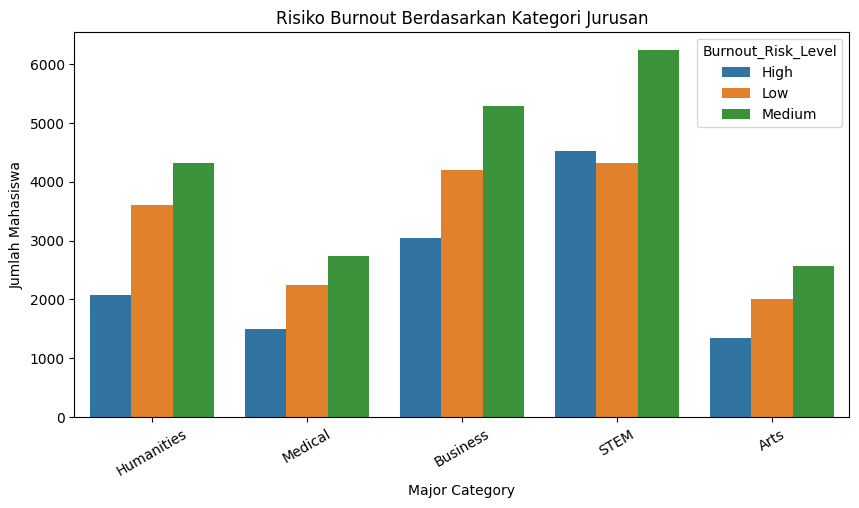

In [11]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Major_Category",
    hue="Burnout_Risk_Level"
)

plt.title("Risiko Burnout Berdasarkan Kategori Jurusan")
plt.xlabel("Major Category")
plt.ylabel("Jumlah Mahasiswa")
plt.xticks(rotation=30)
plt.show()

Grafik menunjukkan jumlah mahasiswa pada kategori risiko burnout Low, Medium, dan High untuk setiap kategori jurusan.

- Kategori **STEM** memiliki jumlah mahasiswa paling banyak pada seluruh tingkat risiko burnout.
- Kategori **Business** berada pada urutan berikutnya, sedangkan **Arts** memiliki jumlah mahasiswa paling sedikit.
- Kelas **Medium** menjadi kategori risiko yang paling banyak ditemukan pada hampir seluruh jurusan.
- Jumlah mahasiswa dengan risiko **High** paling banyak terlihat pada kategori STEM.

Namun, grafik ini menampilkan **jumlah absolut mahasiswa**, bukan persentase pada setiap jurusan. Tingginya jumlah kasus pada STEM dapat dipengaruhi oleh jumlah mahasiswa STEM yang memang lebih banyak dalam dataset.


## **4. Data Preparation**

### **4.1 Cek Missing Value**

In [12]:
print("Jumlah Missing Value: ")
df.isnull().sum()

Jumlah Missing Value: 


Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

### **4.2 Cek Data Duplikat**

In [13]:
print("Jumlah Data Duplikat: ")
df.duplicated().sum()

Jumlah Data Duplikat: 


np.int64(0)

### **4.3 Cek Outlier**

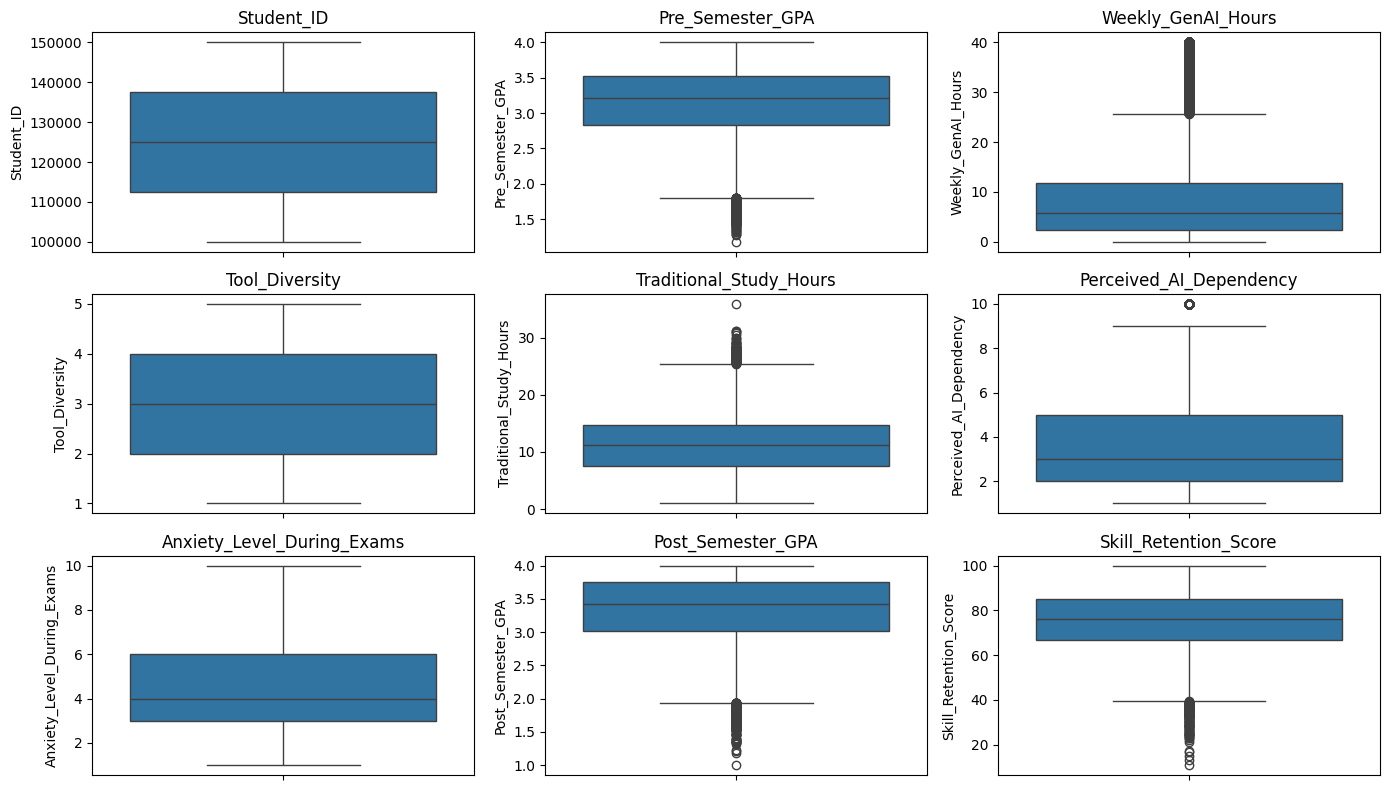


Jumlah Outlier :
Student_ID: 0 outlier

Jumlah Outlier :
Pre_Semester_GPA: 328 outlier

Jumlah Outlier :
Weekly_GenAI_Hours: 2583 outlier

Jumlah Outlier :
Tool_Diversity: 0 outlier

Jumlah Outlier :
Traditional_Study_Hours: 161 outlier

Jumlah Outlier :
Perceived_AI_Dependency: 190 outlier

Jumlah Outlier :
Anxiety_Level_During_Exams: 0 outlier

Jumlah Outlier :
Post_Semester_GPA: 346 outlier

Jumlah Outlier :
Skill_Retention_Score: 216 outlier


In [14]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols

plt.figure(figsize=(14, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print("\nJumlah Outlier :")
    print(f"{col}: {len(outliers)} outlier")

### **4.4 Feature Engineering**

In [15]:
df["GenAI_Study_Ratio"] = df["Weekly_GenAI_Hours"] / (df["Traditional_Study_Hours"] + 1)

df["GenAI_Usage_Category"] = pd.cut(
    df["Weekly_GenAI_Hours"],
    bins=[-1, 5, 15, 40],
    labels=["Low Usage", "Moderate Usage", "High Usage"]
)

df[["Weekly_GenAI_Hours", "Traditional_Study_Hours", "GenAI_Study_Ratio", "GenAI_Usage_Category"]].head()

,Weekly_GenAI_Hours,Traditional_Study_Hours,GenAI_Study_Ratio,GenAI_Usage_Category
0,23.31,8.13,2.553122,High Usage
1,1.12,16.65,0.063456,Low Usage
2,21.26,10.35,1.873128,High Usage
3,1.82,15.23,0.112138,Low Usage
4,9.29,12.55,0.685609,Moderate Usage


### **4.5 Feature Selection**
Variabel `Burnout_Risk_Level` digunakan sebagai target. `Student_ID` tidak digunakan karena hanya berfungsi sebagai identitas. `Post_Semester_GPA` dan `Skill_Retention_Score` juga tidak digunakan untuk menghindari data leakage dalam sistem peringatan dini.

In [16]:
drop_columns = [
    "Student_ID",
    "Burnout_Risk_Level",
    "Post_Semester_GPA",
    "Skill_Retention_Score"
]

X = df.drop(columns=drop_columns)
y = df["Burnout_Risk_Level"]

print("Jumlah fitur:", X.shape[1])
print("Target:", y.name)

Jumlah fitur: 14
Target: Burnout_Risk_Level


### **4.6 Encoding Target**
Target yang masih berbentuk kategori diubah menjadi angka agar dapat diproses oleh algoritma machine learning.

In [17]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)


['High' 'Low' 'Medium']


### **4.7 Pemisahan Kolom Kategorikal dan Numerik**

In [18]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "bool", "category"]).columns

print("Kolom numerik:", numeric_features)
print("Kolom kategorikal:", categorical_features)

Kolom numerik: Index(['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity',
       'Traditional_Study_Hours', 'Perceived_AI_Dependency',
       'Anxiety_Level_During_Exams', 'GenAI_Study_Ratio'],
      dtype='str')
Kolom kategorikal: Index(['Major_Category', 'Year_of_Study', 'Primary_Use_Case',
       'Prompt_Engineering_Skill', 'Paid_Subscription', 'Institutional_Policy',
       'GenAI_Usage_Category'],
      dtype='str')


C:\Users\Asus\AppData\Local\Temp\ipykernel_17480\1323072871.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "bool", "category"]).columns


### **4.8 Encoding dan Standardisasi Fitur**
Fitur kategorikal diproses menggunakan One-Hot Encoding, sedangkan fitur numerik distandardisasi menggunakan StandardScaler.

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

### **4.9 Train Test Split**
Dataset dibagi menjadi 80% data latih dan 20% data uji. Parameter stratify digunakan agar distribusi kelas pada kedua data tetap seimbang.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Data training:", X_train.shape)
print("Data testing:", X_test.shape)

Data training: (40000, 14)
Data testing: (10000, 14)


## **5. Modeling**

### **5.1 Pemilihan dan Pelatihan Model**
Tiga algoritma digunakan sebagai perbandingan, yaitu Logistic Regression, Random Forest, dan Gradient Boosting. Model dengan hasil evaluasi terbaik akan dipilih sebagai model final.

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("=" * 53)
    print("Model:", name)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Model: Logistic Regression
Accuracy: 0.5381
              precision    recall  f1-score   support

        High       0.67      0.47      0.55      2497
         Low       0.55      0.50      0.52      3274
      Medium       0.49      0.61      0.54      4229

    accuracy                           0.54     10000
   macro avg       0.57      0.53      0.54     10000
weighted avg       0.55      0.54      0.54     10000

Model: Random Forest
Accuracy: 0.5152
              precision    recall  f1-score   support

        High       0.64      0.48      0.55      2497
         Low       0.50      0.48      0.49      3274
      Medium       0.48      0.56      0.52      4229

    accuracy                           0.52     10000
   macro avg       0.54      0.51      0.52     10000
weighted avg       0.53      0.52      0.52     10000

Model: Gradient Boosting
Accuracy: 0.5348
              precision    recall  f1-score   support

        High       0.66      0.47      0.55      2497
     

### **5.2 Perbandingan Model**

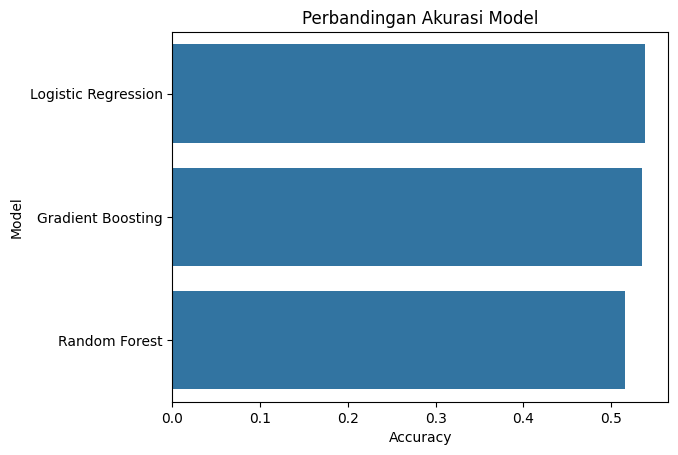

In [22]:
results_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
}).sort_values(by="Accuracy", ascending=False)

results_df

sns.barplot(data=results_df, x="Accuracy", y="Model")
plt.title("Perbandingan Akurasi Model")
plt.show()

### **5.3 Hyperparameter Tuning**

In [34]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best Score: 0.5347135372458912


## **6. Evaluasi**

### **6.1 Evaluasi Random Forest Hasil Tuning**

In [24]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))

Accuracy: 0.5316
              precision    recall  f1-score   support

        High       0.66      0.47      0.55      2497
         Low       0.54      0.48      0.51      3274
      Medium       0.49      0.61      0.54      4229

    accuracy                           0.53     10000
   macro avg       0.56      0.52      0.53     10000
weighted avg       0.55      0.53      0.53     10000



Model final: Logistic Regression
File berhasil dibuat:
- model_evaluation.csv
- burnout_model.pkl
- label_encoder.pkl


,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,Recall High
0,Logistic Regression,0.5381,0.5684,0.5251,0.5381,0.4666
1,Gradient Boosting,0.5348,0.5642,0.5230,0.5357,0.4734
2,Random Forest Tuning,0.5316,0.5617,0.5187,0.5315,0.4666
3,Random Forest,0.5152,0.5397,0.5076,0.5185,0.4786


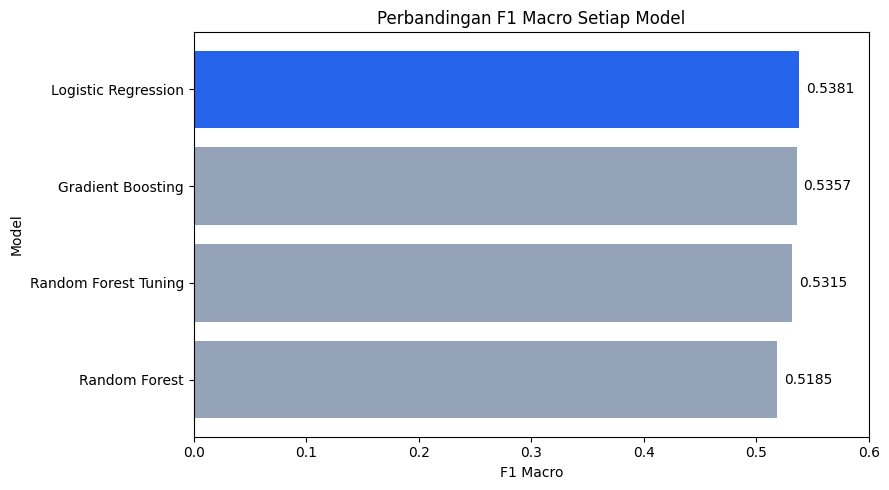

In [ ]:
candidate_models = {}

# Melatih ulang ketiga model baseline menggunakan pipeline yang sama.
for model_name, estimator in models.items():
    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )
    model_pipeline.fit(X_train, y_train)
    candidate_models[model_name] = model_pipeline


candidate_models["Random Forest Tuning"] = grid_search.best_estimator_

high_label = label_encoder.transform(["High"])[0]
evaluation_rows = []

for model_name, trained_model in candidate_models.items():
    prediction = trained_model.predict(X_test)

    recall_per_class = recall_score(
        y_test,
        prediction,
        labels=[high_label],
        average=None,
        zero_division=0,
    )

    evaluation_rows.append(
        {
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, prediction),
            "Precision Macro": precision_score(
                y_test,
                prediction,
                average="macro",
                zero_division=0,
            ),
            "Recall Macro": recall_score(
                y_test,
                prediction,
                average="macro",
                zero_division=0,
            ),
            "F1 Macro": f1_score(
                y_test,
                prediction,
                average="macro",
                zero_division=0,
            ),
            "Recall High": recall_per_class[0],
        }
    )

final_comparison = (
    pd.DataFrame(evaluation_rows)
    .sort_values("F1 Macro", ascending=False)
    .reset_index(drop=True)
)


final_model_name = final_comparison.loc[0, "Model"]
best_model = candidate_models[final_model_name]


final_comparison.to_csv("model_evaluation.csv", index=False)
joblib.dump(best_model, "burnout_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("Model final:", final_model_name)
print("File berhasil dibuat:")
print("- model_evaluation.csv")
print("- burnout_model.pkl")
print("- label_encoder.pkl")

display(final_comparison.round(4))

plot_df = final_comparison.sort_values(
    "F1 Macro",
    ascending=True
)

colors = [
    "#2563EB" if model == final_model_name else "#94A3B8"
    for model in plot_df["Model"]
]

plt.figure(figsize=(9, 5))

bars = plt.barh(
    plot_df["Model"],
    plot_df["F1 Macro"],
    color=colors
)

plt.bar_label(
    bars,
    labels=[
        f"{value:.4f}"
        for value in plot_df["F1 Macro"]
    ],
    padding=5
)

plt.title("Perbandingan F1 Macro Setiap Model")
plt.xlabel("F1 Macro")
plt.ylabel("Model")
plt.xlim(0, 0.60)
plt.tight_layout()

plt.savefig(
    "perbandingan_f1_macro.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### **6.2 Confusion Matrix**

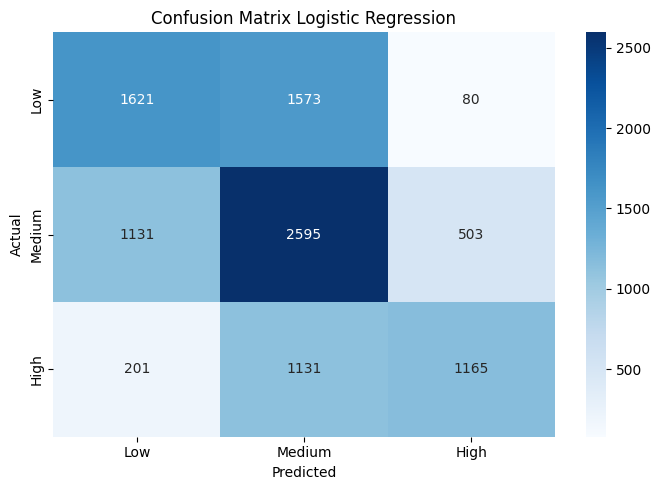

In [26]:
display_order = ["Low", "Medium", "High"]
display_labels = label_encoder.transform(display_order)

y_pred_final = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred_final,
    labels=display_labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=display_order,
    yticklabels=display_order
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Logistic Regression")
plt.tight_layout()
plt.show()

Confusion matrix menunjukkan bahwa Logistic Regression memprediksi dengan benar 5.381 dari 10.000 data testing, sehingga menghasilkan accuracy sebesar 53,81%.

- Sebanyak 1.165 mahasiswa kategori High diprediksi dengan benar.
- Sebanyak 1.621 mahasiswa kategori Low diprediksi dengan benar.
- Sebanyak 2.595 mahasiswa kategori Medium diprediksi dengan benar.
- Kelas Medium memiliki recall tertinggi, yaitu sekitar 61,36%.
- Kesalahan terbesar terjadi ketika kelas Low dan High diprediksi sebagai Medium.

Model cenderung lebih sering memprediksi kelas Medium karena kategori tersebut merupakan kelas dengan jumlah data terbesar. Kemampuan mendeteksi kelas High masih terbatas, sehingga model hanya digunakan sebagai alat analisis awal dan bukan diagnosis.

### **6.3 Feature Importance**

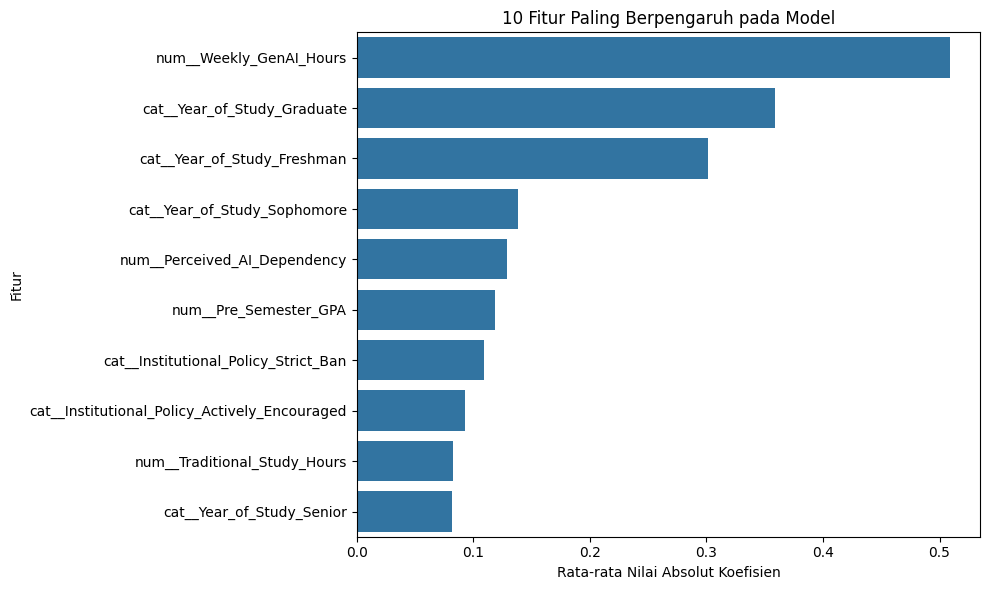

In [27]:
final_estimator = best_model.named_steps["model"]
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficient_importance = np.mean(
    np.abs(final_estimator.coef_),
    axis=0
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": coefficient_importance
}).sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("10 Fitur Paling Berpengaruh pada Model")
plt.xlabel("Rata-rata Nilai Absolut Koefisien")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

### **7. Menyimpan Model**

In [28]:
joblib.dump(best_model, "burnout_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("Model final berhasil disimpan sebagai burnout_model.pkl")
print("Label encoder berhasil disimpan sebagai label_encoder.pkl")

Model final berhasil disimpan sebagai burnout_model.pkl
Label encoder berhasil disimpan sebagai label_encoder.pkl


In [ ]:
%%writefile app.py

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import streamlit as st


APP_DIR = Path(__file__).resolve().parent
DATA_CANDIDATES = [
    APP_DIR / "ai_student_impact_dataset (1).csv",
    APP_DIR.parent / ".cache" / "ai_student_impact_dataset (1).csv",
]
MODEL_CANDIDATES = [
    APP_DIR / "burnout_model.pkl",
]
ENCODER_PATH = APP_DIR / "label_encoder.pkl"
METRICS_PATH = APP_DIR / "model_evaluation.csv"

COLORS = {
    "navy": "#102A43",
    "blue": "#2563EB",
    "cyan": "#06B6D4",
    "green": "#10B981",
    "yellow": "#F59E0B",
    "red": "#EF4444",
    "muted": "#64748B",
    "surface": "#FFFFFF",
    "background": "#F4F7FB",
}
RISK_COLORS = {
    "Low": COLORS["green"],
    "Medium": COLORS["yellow"],
    "High": COLORS["red"],
}

st.set_page_config(
    page_title="Student Burnout Intelligence",
    layout="wide",
    initial_sidebar_state="expanded",
)


def apply_css():
    st.markdown(
        """
        <style>
        @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&display=swap');

        html, body, [class*="css"] {
            font-family: "Inter", sans-serif;
        }

        .stApp {
            background: #F4F7FB;
            color: #102A43;
        }

        [data-testid="stSidebar"] {
            background: #102A43;
            border-right: 1px solid rgba(255, 255, 255, 0.08);
        }

        [data-testid="stSidebar"] * {
            color: #E2E8F0;
        }

        [data-testid="stSidebar"] .stRadio label {
            padding: 0.55rem 0.7rem;
            border-radius: 6px;
            margin-bottom: 0.25rem;
        }

        [data-testid="stSidebar"] .stRadio label:hover {
            background: rgba(255, 255, 255, 0.08);
        }

        [data-testid="stSidebar"] hr {
            border-color: rgba(255, 255, 255, 0.12);
        }

        .block-container {
            max-width: 1400px;
            padding-top: 1.6rem;
            padding-bottom: 3rem;
        }

        h1, h2, h3 {
            color: #102A43;
            letter-spacing: 0;
        }

        .page-eyebrow {
            color: #2563EB;
            font-size: 0.78rem;
            font-weight: 700;
            letter-spacing: 0.08em;
            text-transform: uppercase;
            margin-bottom: 0.35rem;
        }

        .page-title {
            color: #102A43;
            font-size: 2rem;
            font-weight: 700;
            line-height: 1.2;
            margin: 0;
        }

        .page-subtitle {
            color: #64748B;
            font-size: 0.98rem;
            line-height: 1.65;
            max-width: 850px;
            margin-top: 0.55rem;
            margin-bottom: 1.5rem;
        }

        .hero {
            min-height: 310px;
            padding: 2.6rem;
            border-radius: 8px;
            background:
                linear-gradient(110deg, rgba(9, 30, 66, 0.97), rgba(37, 99, 235, 0.88)),
                radial-gradient(circle at 80% 20%, #22D3EE 0, transparent 33%);
            color: white;
            display: flex;
            flex-direction: column;
            justify-content: center;
            box-shadow: 0 16px 40px rgba(15, 42, 67, 0.16);
        }

        .hero-tag {
            display: inline-block;
            width: fit-content;
            padding: 0.35rem 0.7rem;
            border: 1px solid rgba(255, 255, 255, 0.28);
            border-radius: 999px;
            font-size: 0.78rem;
            font-weight: 600;
            margin-bottom: 1rem;
            background: rgba(255, 255, 255, 0.08);
        }

        .hero h1 {
            color: white;
            max-width: 760px;
            font-size: 2.65rem;
            line-height: 1.12;
            margin: 0;
        }

        .hero p {
            max-width: 720px;
            color: #DCEBFF;
            line-height: 1.7;
            margin: 1rem 0 0;
        }

        .metric-card, .info-card, .result-card {
            background: #FFFFFF;
            border: 1px solid #E2E8F0;
            border-radius: 8px;
            padding: 1.15rem 1.25rem;
            box-shadow: 0 6px 18px rgba(15, 42, 67, 0.05);
        }

        .metric-label {
            color: #64748B;
            font-size: 0.78rem;
            font-weight: 600;
            text-transform: uppercase;
            letter-spacing: 0.04em;
        }

        .metric-value {
            color: #102A43;
            font-size: 1.65rem;
            font-weight: 700;
            margin-top: 0.3rem;
        }

        .metric-note {
            color: #64748B;
            font-size: 0.78rem;
            margin-top: 0.25rem;
        }

        .section-title {
            color: #102A43;
            font-size: 1.15rem;
            font-weight: 700;
            margin: 1.7rem 0 0.7rem;
        }

        .info-card h3 {
            font-size: 1rem;
            margin: 0 0 0.45rem;
        }

        .info-card p {
            color: #64748B;
            font-size: 0.88rem;
            line-height: 1.6;
            margin: 0;
        }

        .insight-box {
            padding: 1rem 1.1rem;
            border-left: 4px solid #2563EB;
            border-radius: 0 6px 6px 0;
            background: #EFF6FF;
            color: #334E68;
            font-size: 0.9rem;
            line-height: 1.6;
        }

        .status-chip {
            display: inline-block;
            padding: 0.3rem 0.65rem;
            border-radius: 999px;
            background: #DCFCE7;
            color: #166534;
            font-size: 0.75rem;
            font-weight: 700;
        }

        .footer {
            color: #94A3B8;
            text-align: center;
            font-size: 0.78rem;
            padding-top: 2rem;
        }

        div[data-testid="stForm"] {
            background: #FFFFFF;
            border: 1px solid #E2E8F0;
            border-radius: 8px;
            padding: 1.2rem;
        }

        div[data-testid="stForm"] label,
        div[data-testid="stForm"] label p,
        div[data-testid="stForm"] [data-testid="stWidgetLabel"] p {
            color: #334E68 !important;
            font-weight: 600 !important;
            opacity: 1 !important;
        }

        div[data-testid="stForm"] small {
            color: #64748B !important;
            opacity: 1 !important;
        }

        div[data-testid="stForm"] [data-baseweb="select"] *,
        div[data-testid="stForm"] input {
            color: #102A43 !important;
        }

        div[data-testid="stForm"] [data-testid="stSlider"] p {
            color: #334E68 !important;
            opacity: 1 !important;
        }

        div[data-testid="stForm"] [data-testid="stSliderThumbValue"] {
            color: #EF4444 !important;
        }

        /* Pastikan semua label widget terbaca pada tema browser terang/gelap. */
        [data-testid="stWidgetLabel"] p,
        [data-testid="stWidgetLabel"] label,
        [data-testid="stSlider"] p {
            color: #334E68 !important;
            opacity: 1 !important;
            font-weight: 600 !important;
        }

        /* Input dan filter menggunakan permukaan terang dengan teks gelap. */
        div[data-baseweb="select"] > div,
        div[data-baseweb="input"] > div,
        [data-testid="stNumberInput"] > div > div {
            background: #FFFFFF !important;
            border-color: #CBD5E1 !important;
            color: #102A43 !important;
        }

        div[data-baseweb="select"] *,
        div[data-baseweb="input"] *,
        [data-testid="stNumberInput"] input {
            color: #102A43 !important;
        }

        div[data-baseweb="tag"] {
            background: #DBEAFE !important;
        }

        div[data-baseweb="tag"] span,
        div[data-baseweb="tag"] svg {
            color: #1D4ED8 !important;
            fill: #1D4ED8 !important;
        }

        /* Expander filter dan data pendukung. */
        [data-testid="stExpander"] {
            background: #FFFFFF !important;
            border: 1px solid #D7E2F0 !important;
            border-radius: 8px !important;
            overflow: hidden;
        }

        [data-testid="stExpander"] summary {
            background: #EAF2FF !important;
        }

        [data-testid="stExpander"] summary p,
        [data-testid="stExpander"] summary svg {
            color: #173B67 !important;
            fill: #173B67 !important;
            font-weight: 700 !important;
        }

        /* Tab dokumentasi tetap terbaca meskipun browser memakai dark mode. */
        [data-testid="stTabs"] button {
            color: #52677D !important;
        }

        [data-testid="stTabs"] button p {
            color: #52677D !important;
            font-weight: 600 !important;
        }

        [data-testid="stTabs"] button[aria-selected="true"] p {
            color: #1D4ED8 !important;
        }

        [data-testid="stTabs"] [data-baseweb="tab-highlight"] {
            background-color: #2563EB !important;
        }

        div.stButton > button,
        div[data-testid="stFormSubmitButton"] > button {
            width: 100%;
            min-height: 44px;
            background: #2563EB;
            color: white;
            border: 0;
            border-radius: 6px;
            font-weight: 700;
        }

        div.stButton > button:hover,
        div[data-testid="stFormSubmitButton"] > button:hover {
            background: #1D4ED8;
            color: white;
        }

        [data-testid="stMetric"] {
            background: #FFFFFF;
            border: 1px solid #E2E8F0;
            border-radius: 8px;
            padding: 0.9rem 1rem;
        }

        @media (max-width: 768px) {
            .block-container {
                padding-top: 1rem;
            }
            .hero {
                min-height: auto;
                padding: 1.5rem;
            }
            .hero h1 {
                font-size: 1.8rem;
            }
            .page-title {
                font-size: 1.55rem;
            }
        }
        </style>
        """,
        unsafe_allow_html=True,
    )


@st.cache_data(show_spinner=False)
def load_data():
    for data_path in DATA_CANDIDATES:
        if data_path.exists():
            return pd.read_csv(data_path), data_path
    return None, None


@st.cache_resource(show_spinner=False)
def load_artifacts():
    model_path = next((path for path in MODEL_CANDIDATES if path.exists()), None)
    if model_path is None or not ENCODER_PATH.exists():
        return None, None
    return joblib.load(model_path), joblib.load(ENCODER_PATH)


@st.cache_data(show_spinner=False)
def load_evaluation():
    if not METRICS_PATH.exists():
        return None
    return pd.read_csv(METRICS_PATH)


def get_model_name(model):
    if model is None:
        return "Belum tersedia"
    if hasattr(model, "named_steps") and "model" in model.named_steps:
        model = model.named_steps["model"]
    readable_names = {
        "LogisticRegression": "Logistic Regression",
        "RandomForestClassifier": "Random Forest",
        "GradientBoostingClassifier": "Gradient Boosting",
    }
    class_name = model.__class__.__name__
    return readable_names.get(class_name, class_name)


def page_header(eyebrow, title, subtitle):
    st.markdown(
        f"""
        <div class="page-eyebrow">{eyebrow}</div>
        <div class="page-title">{title}</div>
        <div class="page-subtitle">{subtitle}</div>
        """,
        unsafe_allow_html=True,
    )


def metric_card(label, value, note):
    st.markdown(
        f"""
        <div class="metric-card">
            <div class="metric-label">{label}</div>
            <div class="metric-value">{value}</div>
            <div class="metric-note">{note}</div>
        </div>
        """,
        unsafe_allow_html=True,
    )


def section_title(title):
    st.markdown(f'<div class="section-title">{title}</div>', unsafe_allow_html=True)


def style_figure(fig, height=400):
    fig.update_layout(
        height=height,
        margin=dict(l=16, r=16, t=55, b=16),
        paper_bgcolor="#FFFFFF",
        plot_bgcolor="#FFFFFF",
        font=dict(family="Inter", color=COLORS["navy"]),
        title_font=dict(size=16, color=COLORS["navy"]),
        legend_title_text="",
        legend=dict(font=dict(color=COLORS["navy"])),
        hoverlabel=dict(bgcolor="#102A43", font_color="white"),
    )
    fig.update_xaxes(
        showgrid=False,
        linecolor="#E2E8F0",
        tickfont=dict(color=COLORS["navy"]),
        title_font=dict(color=COLORS["navy"]),
    )
    fig.update_yaxes(
        gridcolor="#EDF2F7",
        zeroline=False,
        tickfont=dict(color=COLORS["navy"]),
        title_font=dict(color=COLORS["navy"]),
    )
    return fig


def format_number(value, digits=1):
    if pd.isna(value):
        return "-"
    return f"{value:,.{digits}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def render_sidebar():
    with st.sidebar:
        st.markdown(
            """
            <div style="padding: 0.4rem 0 1rem;">
                <div style="font-size: 1.15rem; font-weight: 700; color: white;">
                    Student Burnout
                </div>
                <div style="font-size: 0.78rem; color: #94A3B8; margin-top: 0.25rem;">
                    GenAI Impact Intelligence
                </div>
            </div>
            """,
            unsafe_allow_html=True,
        )
        st.markdown("---")
        page = st.radio(
            "NAVIGASI",
            [
                "Beranda",
                "Dashboard EDA",
                "Prediksi Burnout",
                "Dokumentasi",
            ],
            label_visibility="collapsed",
        )
        st.markdown("---")
        st.markdown(
            """
            <div style="font-size: 0.72rem; color: #94A3B8; line-height: 1.6;">
                Metode: CRISP-DM<br>
                Subtema: Education & Risk Prediction<br>
                Versi aplikasi: 1.0
            </div>
            """,
            unsafe_allow_html=True,
        )
    return page


def render_home(df):
    st.markdown(
        """
        <div class="hero">
            <div class="hero-tag">Education Analytics • Early Warning System</div>
            <h1>Prediksi Risiko Burnout Mahasiswa di Era Generative AI</h1>
            <p>
                Dashboard ini menganalisis hubungan penggunaan GenAI, pola belajar,
                kecemasan ujian, dan ketergantungan AI dengan tingkat risiko burnout
                mahasiswa. Model klasifikasi memberikan prediksi Low, Medium, atau High
                sebagai dukungan untuk tindakan pencegahan lebih awal.
            </p>
        </div>
        """,
        unsafe_allow_html=True,
    )

    section_title("Ringkasan proyek")
    if df is not None:
        c1, c2, c3, c4 = st.columns(4)
        with c1:
            metric_card("Jumlah Data", f"{len(df):,}".replace(",", "."), "Record mahasiswa")
        with c2:
            metric_card("Jumlah Variabel", str(df.shape[1]), "Fitur dan target")
        with c3:
            metric_card(
                "Rata-rata GenAI",
                f"{format_number(df['Weekly_GenAI_Hours'].mean())} jam",
                "Penggunaan per minggu",
            )
        with c4:
            high_rate = (df["Burnout_Risk_Level"] == "High").mean() * 100
            metric_card("Risiko Tinggi", f"{format_number(high_rate)}%", "Dari seluruh mahasiswa")
    else:
        st.warning("Dataset belum ditemukan. Letakkan file CSV di folder yang sama dengan app.py.")

    section_title("Latar belakang dan tujuan")
    left, right = st.columns([1.2, 1])
    with left:
        st.markdown(
            """
            <div class="info-card">
                <h3>Latar Belakang Masalah</h3>
                <p>
                    Generative AI membantu mahasiswa menyusun ide, meringkas bacaan,
                    melakukan debugging, dan menyelesaikan tugas. Namun, penggunaan
                    yang tidak terkontrol dapat berkaitan dengan ketergantungan AI,
                    berkurangnya pola belajar tradisional, kecemasan, dan burnout.
                </p>
            </div>
            """,
            unsafe_allow_html=True,
        )
    with right:
        st.markdown(
            """
            <div class="info-card">
                <h3>Tujuan Proyek</h3>
                <p>
                    Menghasilkan eksplorasi data yang informatif, mengetahui faktor
                    yang berkaitan dengan burnout, membangun model klasifikasi, dan
                    menyediakan prediksi risiko secara real-time melalui Streamlit.
                </p>
            </div>
            """,
            unsafe_allow_html=True,
        )

    section_title("Fitur aplikasi")
    c1, c2, c3 = st.columns(3)
    cards = [
        (
            c1,
            "Dashboard EDA",
            "Filter data dan visualisasi interaktif untuk mengeksplorasi karakteristik mahasiswa.",
        ),
        (
            c2,
            "Prediksi Real-Time",
            "Masukkan kondisi mahasiswa dan dapatkan tingkat risiko beserta probabilitasnya.",
        ),
        (
            c3,
            "Dokumentasi Model",
            "Informasi metode CRISP-DM, fitur, evaluasi, penggunaan aplikasi, dan tim.",
        ),
    ]
    for column, title, description in cards:
        with column:
            st.markdown(
                f'<div class="info-card"><h3>{title}</h3><p>{description}</p></div>',
                unsafe_allow_html=True,
            )


def render_eda(df):
    page_header(
        "Exploratory Data Analysis",
        "Dashboard Eksplorasi Data",
        "Gunakan filter untuk melihat pola penggunaan GenAI, kondisi belajar, dan risiko burnout pada kelompok mahasiswa tertentu.",
    )

    if df is None:
        st.error("Dataset belum ditemukan. Pastikan file CSV berada di folder aplikasi.")
        return

    with st.expander("Filter data", expanded=True):
        f1, f2, f3, f4 = st.columns(4)
        with f1:
            selected_major = st.multiselect(
                "Kategori jurusan",
                sorted(df["Major_Category"].dropna().unique()),
                default=sorted(df["Major_Category"].dropna().unique()),
            )
        with f2:
            selected_year = st.multiselect(
                "Tahun studi",
                sorted(df["Year_of_Study"].dropna().unique()),
                default=sorted(df["Year_of_Study"].dropna().unique()),
            )
        with f3:
            selected_risk = st.multiselect(
                "Risiko burnout",
                ["Low", "Medium", "High"],
                default=["Low", "Medium", "High"],
            )
        with f4:
            gpa_range = st.slider(
                "Rentang GPA awal",
                min_value=float(df["Pre_Semester_GPA"].min()),
                max_value=float(df["Pre_Semester_GPA"].max()),
                value=(
                    float(df["Pre_Semester_GPA"].min()),
                    float(df["Pre_Semester_GPA"].max()),
                ),
                step=0.01,
            )

    filtered = df[
        df["Major_Category"].isin(selected_major)
        & df["Year_of_Study"].isin(selected_year)
        & df["Burnout_Risk_Level"].isin(selected_risk)
        & df["Pre_Semester_GPA"].between(gpa_range[0], gpa_range[1])
    ].copy()

    if filtered.empty:
        st.warning("Tidak ada data yang sesuai dengan kombinasi filter tersebut.")
        return

    c1, c2, c3, c4 = st.columns(4)
    high_rate = (filtered["Burnout_Risk_Level"] == "High").mean() * 100
    with c1:
        metric_card("Data Terpilih", f"{len(filtered):,}".replace(",", "."), "Setelah filter")
    with c2:
        metric_card(
            "GenAI Mingguan",
            f"{format_number(filtered['Weekly_GenAI_Hours'].mean())} jam",
            "Nilai rata-rata",
        )
    with c3:
        metric_card(
            "Ketergantungan AI",
            format_number(filtered["Perceived_AI_Dependency"].mean()),
            "Skala 1 sampai 10",
        )
    with c4:
        metric_card("Risiko Tinggi", f"{format_number(high_rate)}%", "Proporsi data terpilih")

    section_title("Komposisi risiko dan pola penggunaan")
    left, right = st.columns(2)
    with left:
        risk_counts = (
            filtered["Burnout_Risk_Level"]
            .value_counts()
            .reindex(["Low", "Medium", "High"], fill_value=0)
            .reset_index()
        )
        risk_counts.columns = ["Burnout_Risk_Level", "Jumlah"]
        fig = px.pie(
            risk_counts,
            names="Burnout_Risk_Level",
            values="Jumlah",
            hole=0.62,
            title="Distribusi Risiko Burnout",
            color="Burnout_Risk_Level",
            color_discrete_map=RISK_COLORS,
        )
        fig.update_traces(textposition="outside", textinfo="percent+label")
        st.plotly_chart(style_figure(fig), use_container_width=True)

    with right:
        major_risk = (
            filtered.groupby(["Major_Category", "Burnout_Risk_Level"], observed=True)
            .size()
            .reset_index(name="Jumlah")
        )
        fig = px.bar(
            major_risk,
            x="Major_Category",
            y="Jumlah",
            color="Burnout_Risk_Level",
            barmode="group",
            title="Risiko Burnout Berdasarkan Jurusan",
            category_orders={"Burnout_Risk_Level": ["Low", "Medium", "High"]},
            color_discrete_map=RISK_COLORS,
        )
        fig.update_xaxes(title="Kategori jurusan")
        fig.update_yaxes(title="Jumlah mahasiswa")
        st.plotly_chart(style_figure(fig), use_container_width=True)

    section_title("Hubungan faktor utama dengan burnout")
    chart_variable = st.selectbox(
        "Pilih variabel yang dianalisis",
        [
            "Weekly_GenAI_Hours",
            "Traditional_Study_Hours",
            "Perceived_AI_Dependency",
            "Anxiety_Level_During_Exams",
            "Pre_Semester_GPA",
        ],
        format_func={
            "Weekly_GenAI_Hours": "Penggunaan GenAI per Minggu",
            "Traditional_Study_Hours": "Jam Belajar Tradisional",
            "Perceived_AI_Dependency": "Ketergantungan AI",
            "Anxiety_Level_During_Exams": "Kecemasan Saat Ujian",
            "Pre_Semester_GPA": "GPA Sebelum Semester",
        }.get,
    )

    left, right = st.columns([1.25, 1])
    with left:
        fig = px.box(
            filtered,
            x="Burnout_Risk_Level",
            y=chart_variable,
            color="Burnout_Risk_Level",
            title=f"Distribusi {chart_variable} pada Setiap Tingkat Risiko",
            category_orders={"Burnout_Risk_Level": ["Low", "Medium", "High"]},
            color_discrete_map=RISK_COLORS,
            points=False,
        )
        fig.update_xaxes(title="Tingkat risiko burnout")
        fig.update_yaxes(title=chart_variable)
        st.plotly_chart(style_figure(fig, 430), use_container_width=True)

    with right:
        summary = (
            filtered.groupby("Burnout_Risk_Level", observed=True)[chart_variable]
            .agg(["mean", "median", "std"])
            .reindex(["Low", "Medium", "High"])
            .round(2)
            .reset_index()
        )
        summary.columns = ["Risiko", "Rata-rata", "Median", "Standar Deviasi"]
        st.markdown("##### Ringkasan statistik")
        st.dataframe(summary, use_container_width=True, hide_index=True)

        low_mean = summary.loc[summary["Risiko"] == "Low", "Rata-rata"]
        high_mean = summary.loc[summary["Risiko"] == "High", "Rata-rata"]
        if not low_mean.empty and not high_mean.empty:
            difference = high_mean.iloc[0] - low_mean.iloc[0]
            direction = "lebih tinggi" if difference >= 0 else "lebih rendah"
            st.markdown(
                f"""
                <div class="insight-box">
                    Pada data terpilih, rata-rata <b>{chart_variable}</b> pada kelompok
                    risiko tinggi adalah <b>{abs(difference):.2f} {direction}</b>
                    dibandingkan kelompok risiko rendah. Temuan ini menunjukkan pola
                    deskriptif dan tidak langsung membuktikan hubungan sebab-akibat.
                </div>
                """,
                unsafe_allow_html=True,
            )

    section_title("Korelasi antarvariabel numerik")
    correlation_columns = [
        "Pre_Semester_GPA",
        "Weekly_GenAI_Hours",
        "Tool_Diversity",
        "Traditional_Study_Hours",
        "Perceived_AI_Dependency",
        "Anxiety_Level_During_Exams",
    ]
    corr = filtered[correlation_columns].corr()
    labels = [
        "GPA Awal",
        "Jam GenAI",
        "Keragaman Tool",
        "Belajar Tradisional",
        "Ketergantungan AI",
        "Kecemasan",
    ]
    fig = go.Figure(
        data=go.Heatmap(
            z=corr.values,
            x=labels,
            y=labels,
            colorscale=[[0, "#2563EB"], [0.5, "#FFFFFF"], [1, "#EF4444"]],
            zmin=-1,
            zmax=1,
            text=np.round(corr.values, 2),
            texttemplate="%{text}",
            hovertemplate="%{x} dengan %{y}: %{z:.2f}<extra></extra>",
        )
    )
    fig.update_layout(title="Matriks Korelasi Pearson")
    st.plotly_chart(style_figure(fig, 520), use_container_width=True)

    with st.expander("Lihat data hasil filter"):
        st.dataframe(filtered.head(500), use_container_width=True, hide_index=True)
        st.caption("Tabel dibatasi maksimal 500 baris agar aplikasi tetap ringan.")


def build_prediction_input(values):
    genai_ratio = values["Weekly_GenAI_Hours"] / (
        values["Traditional_Study_Hours"] + 1
    )
    if values["Weekly_GenAI_Hours"] <= 5:
        usage_category = "Low"
    elif values["Weekly_GenAI_Hours"] <= 15:
        usage_category = "Moderate"
    else:
        usage_category = "High"

    values["GenAI_Study_Ratio"] = genai_ratio
    values["GenAI_Usage_Category"] = usage_category
    return pd.DataFrame([values])


def risk_recommendations(risk):
    if risk == "High":
        return [
            "Evaluasi kembali beban belajar dan frekuensi penggunaan GenAI.",
            "Seimbangkan penggunaan AI dengan proses belajar mandiri.",
            "Pertimbangkan konsultasi dengan dosen wali atau layanan konseling kampus.",
        ]
    if risk == "Medium":
        return [
            "Pantau perubahan kecemasan dan ketergantungan terhadap AI.",
            "Tetapkan batas waktu penggunaan GenAI untuk aktivitas akademik.",
            "Pertahankan jadwal istirahat dan belajar tradisional yang konsisten.",
        ]
    return [
        "Pertahankan pola belajar dan penggunaan GenAI yang seimbang.",
        "Gunakan GenAI sebagai alat bantu, bukan sebagai pengganti proses berpikir.",
        "Lakukan pemantauan berkala jika pola belajar atau beban akademik berubah.",
    ]


def render_prediction(df):
    page_header(
        "Prediction & Analysis",
        "Prediksi Risiko Burnout",
        "Masukkan profil dan kebiasaan belajar mahasiswa. Model akan memberikan kelas risiko serta probabilitas prediksi secara real-time.",
    )

    model, encoder = load_artifacts()
    if model is None or encoder is None:
        st.warning(
            "File model belum ditemukan. Letakkan `burnout_model.pkl` "
            "dan `label_encoder.pkl` dalam folder yang sama dengan `app.py`."
        )

    default = {
        "Pre_Semester_GPA": 3.21,
        "Weekly_GenAI_Hours": 5.8,
        "Tool_Diversity": 3,
        "Traditional_Study_Hours": 11.18,
        "Perceived_AI_Dependency": 3,
        "Anxiety_Level_During_Exams": 4,
    }
    if df is not None:
        for key in default:
            default[key] = float(df[key].median())

    with st.form("prediction_form"):
        st.markdown(
            """
            <div class="insight-box" style="margin-bottom: 1rem;">
                Isi berdasarkan kondisi mahasiswa dalam satu semester terakhir.
                Arahkan kursor ke ikon <b></b> pada setiap pertanyaan untuk melihat
                penjelasan lebih lengkap.
            </div>
            """,
            unsafe_allow_html=True,
        )
        st.markdown("#### Faktor utama")
        st.caption(
            "Enam isian berikut merupakan informasi utama yang perlu disesuaikan "
            "dengan kondisi mahasiswa."
        )
        c1, c2, c3 = st.columns(3)
        with c1:
            pre_gpa = st.number_input(
                "IPK/GPA sebelum semester (0,00-4,00)",
                min_value=0.0,
                max_value=4.0,
                value=float(default["Pre_Semester_GPA"]),
                step=0.01,
                help="Masukkan IPK terakhir sebelum semester yang sedang dianalisis. Contoh: 3,22.",
            )
            genai_hours = st.slider(
                "Penggunaan GenAI per minggu (jam)",
                0.0,
                40.0,
                float(default["Weekly_GenAI_Hours"]),
                0.1,
                help="Perkirakan total jam menggunakan ChatGPT, Gemini, Copilot, atau AI lainnya dalam satu minggu.",
            )
        with c2:
            traditional_hours = st.slider(
                "Belajar tanpa bantuan AI per minggu (jam)",
                1.0,
                36.0,
                float(default["Traditional_Study_Hours"]),
                0.1,
                help="Total waktu membaca, mencatat, berdiskusi, dan mengerjakan tugas tanpa bantuan GenAI.",
            )
            dependency = st.slider(
                "Ketergantungan terhadap AI (1-10)",
                1,
                10,
                int(default["Perceived_AI_Dependency"]),
                help="1 berarti hampir tidak bergantung; 10 berarti sangat sulit belajar atau mengerjakan tugas tanpa AI.",
            )
        with c3:
            anxiety = st.slider(
                "Kecemasan saat ujian (1-10)",
                1,
                10,
                int(default["Anxiety_Level_During_Exams"]),
                help="1 berarti sangat tenang; 10 berarti sangat cemas ketika menghadapi ujian.",
            )
            tool_diversity = st.slider(
                "Jumlah aplikasi AI yang digunakan",
                1,
                5,
                int(default["Tool_Diversity"]),
                help="Contoh: memakai ChatGPT, Gemini, dan Copilot berarti memilih nilai 3.",
            )

        with st.expander("Data pendukung (opsional untuk disesuaikan)", expanded=False):
            st.caption(
                "Bagian ini tetap dibutuhkan model, tetapi sudah memiliki nilai "
                "bawaan. Ubah hanya jika ingin hasil yang lebih sesuai dengan profil."
            )
            c1, c2, c3 = st.columns(3)
            with c1:
                major = st.selectbox(
                    "Bidang atau kategori jurusan",
                    ["STEM", "Business", "Medical", "Humanities", "Arts"],
                    format_func={
                        "STEM": "STEM - Sains dan Teknologi",
                        "Business": "Business - Bisnis dan Manajemen",
                        "Medical": "Medical - Kesehatan",
                        "Humanities": "Humanities - Sosial dan Humaniora",
                        "Arts": "Arts - Seni dan Desain",
                    }.get,
                    help="Pilih kategori yang paling sesuai dengan program studi mahasiswa.",
                )
                year = st.selectbox(
                    "Tingkat atau tahun studi",
                    ["Freshman", "Sophomore", "Junior", "Senior", "Graduate"],
                    format_func={
                        "Freshman": "Tahun pertama",
                        "Sophomore": "Tahun kedua",
                        "Junior": "Tahun ketiga",
                        "Senior": "Tahun keempat/akhir",
                        "Graduate": "Pascasarjana",
                    }.get,
                    help="Pilih tingkat studi mahasiswa saat ini.",
                )
            with c2:
                primary_use = st.selectbox(
                    "Tujuan utama menggunakan GenAI",
                    [
                        "Ideation",
                        "Summarizing_Reading",
                        "Copywriting/Drafting",
                        "Debugging/Troubleshooting",
                        "Direct_Answer_Generation",
                    ],
                    format_func={
                        "Ideation": "Mencari ide",
                        "Summarizing_Reading": "Meringkas bacaan",
                        "Copywriting/Drafting": "Menyusun tulisan",
                        "Debugging/Troubleshooting": "Debugging",
                        "Direct_Answer_Generation": "Mendapatkan jawaban langsung",
                    }.get,
                    help="Pilih aktivitas yang paling sering dilakukan menggunakan GenAI.",
                )
                prompt_skill = st.selectbox(
                    "Kemampuan menyusun prompt",
                    ["Beginner", "Intermediate", "Advanced"],
                    format_func={
                        "Beginner": "Pemula",
                        "Intermediate": "Menengah",
                        "Advanced": "Mahir",
                    }.get,
                    help="Nilai kemampuan memberikan instruksi yang jelas kepada AI.",
                )
            with c3:
                institutional_policy = st.selectbox(
                    "Kebijakan kampus mengenai AI",
                    ["Allowed_With_Citation", "Actively_Encouraged", "Strict_Ban"],
                    format_func={
                        "Allowed_With_Citation": "Diizinkan dengan sumber",
                        "Actively_Encouraged": "Didukung kampus",
                        "Strict_Ban": "Dilarang",
                    }.get,
                    help="Pilih aturan kampus terkait penggunaan GenAI.",
                )
                paid_subscription = st.toggle(
                    "Menggunakan layanan AI berbayar",
                    help="Aktifkan jika menggunakan paket AI berbayar.",
                )

        submitted = st.form_submit_button("Analisis Risiko Burnout")

    if not submitted:
        st.markdown(
            """
            <div class="insight-box">
                Hasil prediksi merupakan dukungan analisis berbasis data dan bukan
                diagnosis kesehatan mental. Interpretasikan hasil bersama kondisi
                nyata mahasiswa.
            </div>
            """,
            unsafe_allow_html=True,
        )
        return

    values = {
        "Major_Category": major,
        "Year_of_Study": year,
        "Pre_Semester_GPA": pre_gpa,
        "Weekly_GenAI_Hours": genai_hours,
        "Primary_Use_Case": primary_use,
        "Prompt_Engineering_Skill": prompt_skill,
        "Tool_Diversity": tool_diversity,
        "Paid_Subscription": paid_subscription,
        "Traditional_Study_Hours": traditional_hours,
        "Perceived_AI_Dependency": dependency,
        "Institutional_Policy": institutional_policy,
        "Anxiety_Level_During_Exams": anxiety,
    }
    prediction_data = build_prediction_input(values)

    if model is None or encoder is None:
        st.error("Prediksi belum dapat dijalankan karena file model belum tersedia.")
        with st.expander("Lihat data yang akan dikirim ke model"):
            st.dataframe(prediction_data, use_container_width=True, hide_index=True)
        return

    try:
        encoded_prediction = model.predict(prediction_data)[0]
        predicted_risk = str(encoder.inverse_transform([encoded_prediction])[0])

        probability_map = {}
        if hasattr(model, "predict_proba"):
            probabilities = model.predict_proba(prediction_data)[0]
            model_classes = model.classes_
            decoded_classes = encoder.inverse_transform(model_classes.astype(int))
            probability_map = dict(zip(decoded_classes, probabilities))

        section_title("Hasil analisis")
        risk_color = RISK_COLORS.get(predicted_risk, COLORS["blue"])
        result_left, result_right = st.columns([0.85, 1.15])

        with result_left:
            confidence = probability_map.get(predicted_risk)
            confidence_text = (
                f"{confidence * 100:.1f}%"
                if confidence is not None
                else "Tidak tersedia"
            )
            st.markdown(
                f"""
                <div class="result-card" style="border-top: 5px solid {risk_color};">
                    <div class="metric-label">TINGKAT RISIKO</div>
                    <div style="font-size: 2.4rem; font-weight: 700; color: {risk_color};
                                margin: 0.35rem 0;">{predicted_risk}</div>
                    <div style="color: #64748B;">Probabilitas Prediksi: {confidence_text}</div>
                </div>
                """,
                unsafe_allow_html=True,
            )

        with result_right:
            if probability_map:
                probability_df = pd.DataFrame(
                    {
                        "Risiko": ["Low", "Medium", "High"],
                        "Probabilitas": [
                            probability_map.get("Low", 0),
                            probability_map.get("Medium", 0),
                            probability_map.get("High", 0),
                        ],
                    }
                )
                fig = px.bar(
                    probability_df,
                    x="Probabilitas",
                    y="Risiko",
                    orientation="h",
                    color="Risiko",
                    color_discrete_map=RISK_COLORS,
                    text=probability_df["Probabilitas"].map(lambda x: f"{x * 100:.1f}%"),
                    title="Probabilitas Setiap Kelas",
                )
                fig.update_xaxes(tickformat=".0%", range=[0, 1], title="Probabilitas")
                fig.update_yaxes(title="")
                fig.update_traces(textposition="outside")
                st.plotly_chart(style_figure(fig, 280), use_container_width=True)

        section_title("Rekomendasi awal")
        recommendations = risk_recommendations(predicted_risk)
        for index, recommendation in enumerate(recommendations, start=1):
            st.markdown(f"**{index}.** {recommendation}")

        with st.expander("Detail input dan fitur hasil rekayasa"):
            st.dataframe(prediction_data, use_container_width=True, hide_index=True)
            st.caption(
                "GenAI_Study_Ratio dan GenAI_Usage_Category dihitung otomatis "
                "menggunakan aturan yang sama seperti pada notebook."
            )
    except Exception as error:
        st.error(
            "Prediksi gagal karena struktur input aplikasi tidak sama dengan model "
            f"yang disimpan. Detail error: {error}"
        )
        st.info(
            "Pastikan model dilatih menggunakan daftar fitur yang sama dengan kode "
            "Data Preparation dan seluruh preprocessing disimpan di dalam Pipeline."
        )


def render_documentation(df):
    page_header(
        "About & Documentation",
        "Dokumentasi Proyek",
        "Penjelasan metode, model, evaluasi, cara penggunaan aplikasi, dan informasi tim.",
    )

    tab1, tab2, tab3, tab4 = st.tabs(
        ["Metodologi", "Model & Evaluasi", "Cara Penggunaan", "Informasi Tim"]
    )

    with tab1:
        st.markdown("### Metode CRISP-DM")
        stages = [
            ("1. Business Understanding", "Menentukan masalah, tujuan, manfaat, dan ruang lingkup prediksi burnout."),
            ("2. Data Understanding", "Mengidentifikasi 50.000 record, 16 variabel, distribusi target, dan pola awal data."),
            ("3. Data Preparation", "Memeriksa kualitas data, memilih fitur, membuat fitur baru, encoding, scaling, dan train-test split."),
            ("4. Modeling", "Membandingkan Logistic Regression, Random Forest, dan Gradient Boosting."),
            ("5. Evaluation", "Menilai model menggunakan accuracy, precision, recall, F1-score, classification report, dan confusion matrix."),
            ("6. Deployment", "Menerapkan model terpilih dalam aplikasi Streamlit untuk analisis dan prediksi real-time."),
        ]
        for title, description in stages:
            st.markdown(
                f'<div class="info-card" style="margin-bottom: 0.65rem;"><h3>{title}</h3><p>{description}</p></div>',
                unsafe_allow_html=True,
            )

    with tab2:
        st.markdown("### Penjelasan Model")
        model, encoder = load_artifacts()
        final_model_name = get_model_name(model)

        st.write(
            "Masalah diselesaikan sebagai klasifikasi multikelas dengan target "
            "`Burnout_Risk_Level`: Low, Medium, dan High. Model final dipilih "
            "berdasarkan hasil evaluasi pada data uji, terutama macro F1-score."
        )

        c1, c2 = st.columns(2)
        with c1:
            metric_card(
                "Model Final",
                final_model_name,
                "Hasil perbandingan dan tuning",
            )
        with c2:
            deployment_status = (
                "Siap digunakan"
                if model is not None and encoder is not None
                else "Belum tersedia"
            )
            metric_card(
                "Status Deployment",
                deployment_status,
                "Model dan encoder",
            )

        st.markdown("#### Fitur yang digunakan")
        feature_table = pd.DataFrame(
            [
                ["Major_Category", "Kategorikal", "Kategori bidang studi"],
                ["Year_of_Study", "Kategorikal", "Tingkat tahun studi"],
                ["Pre_Semester_GPA", "Numerik", "GPA sebelum semester"],
                ["Weekly_GenAI_Hours", "Numerik", "Jam penggunaan GenAI per minggu"],
                ["Primary_Use_Case", "Kategorikal", "Tujuan utama penggunaan GenAI"],
                ["Prompt_Engineering_Skill", "Kategorikal", "Kemampuan menyusun prompt"],
                ["Tool_Diversity", "Numerik", "Jumlah jenis tool AI"],
                ["Paid_Subscription", "Boolean", "Status langganan AI berbayar"],
                ["Traditional_Study_Hours", "Numerik", "Jam belajar tradisional"],
                ["Perceived_AI_Dependency", "Numerik", "Tingkat ketergantungan AI"],
                ["Institutional_Policy", "Kategorikal", "Kebijakan institusi"],
                ["Anxiety_Level_During_Exams", "Numerik", "Kecemasan saat ujian"],
                ["GenAI_Study_Ratio", "Rekayasa fitur", "Rasio penggunaan GenAI dan belajar tradisional"],
                ["GenAI_Usage_Category", "Rekayasa fitur", "Kategori intensitas penggunaan GenAI"],
            ],
            columns=["Variabel", "Jenis", "Keterangan"],
        )
        st.dataframe(feature_table, use_container_width=True, hide_index=True)

        st.markdown("#### Metrik evaluasi")
        evaluation_df = load_evaluation()
        if evaluation_df is not None and not evaluation_df.empty:
            display_evaluation = evaluation_df.copy()
            numeric_columns = display_evaluation.select_dtypes(include=np.number).columns
            display_evaluation[numeric_columns] = display_evaluation[
                numeric_columns
            ].round(4)
            st.dataframe(
                display_evaluation,
                use_container_width=True,
                hide_index=True,
            )

            f1_column = next(
                (
                    column
                    for column in display_evaluation.columns
                    if column.lower().replace("-", " ").replace("_", " ")
                    in {"f1 macro", "f1 score macro"}
                ),
                None,
            )
            if f1_column and "Model" in display_evaluation.columns:
                best_row = display_evaluation.loc[
                    display_evaluation[f1_column].idxmax()
                ]
                st.success(
                    f"Model dengan {f1_column} tertinggi pada data testing adalah "
                    f"{best_row['Model']} dengan skor {best_row[f1_column]:.4f}."
                )
        else:
            st.info(
                "File `model_evaluation.csv` belum tersedia. Ekspor tabel hasil "
                "perbandingan model dari notebook agar metrik tampil di bagian ini."
            )

    with tab3:
        st.markdown("### Cara Menggunakan Aplikasi")
        st.markdown(
            """
            1. Buka menu **Dashboard EDA** untuk mengeksplorasi data.
            2. Atur filter jurusan, tahun studi, tingkat risiko, dan GPA.
            3. Buka menu **Prediksi Burnout**.
            4. Isi seluruh profil akademik dan kebiasaan belajar.
            5. Tekan tombol **Analisis Risiko Burnout**.
            6. Baca kelas risiko, probabilitas, dan rekomendasi awal.
            """
        )
        st.markdown("### Menjalankan Secara Lokal")
        st.code(
            "pip install -r requirements.txt\nstreamlit run app.py",
            language="bash",
        )

    with tab4:
        st.markdown("### Informasi Tim")
        st.markdown(
            """
            <div class="info-card" style="max-width: 720px;">
                <div class="metric-label">NAMA TIM</div>
                <div style="font-size: 1.45rem; font-weight: 700; color: #102A43;
                            margin: 0.25rem 0 1.1rem;">WhatIf</div>
                <div class="metric-label">ANGGOTA</div>
                <div style="font-size: 1rem; font-weight: 600; color: #334E68;
                            margin: 0.25rem 0 1.1rem;">Ihwan Fajar Maulana</div>
                <div class="metric-label">PROGRAM STUDI</div>
                <div style="font-size: 1rem; font-weight: 600; color: #334E68;
                            margin-top: 0.25rem;">S1 Sistem Informasi</div>
            </div>
            """,
            unsafe_allow_html=True,
        )
        if df is not None:
            st.caption(
                f"Dataset aktif: {len(df):,} record dan {df.shape[1]} variabel."
            )


def main():
    apply_css()
    df, data_path = load_data()
    page = render_sidebar()

    if page == "Beranda":
        render_home(df)
    elif page == "Dashboard EDA":
        render_eda(df)
    elif page == "Prediksi Burnout":
        render_prediction(df)
    else:
        render_documentation(df)

    st.markdown(
        """
        <div class="footer">
            Student Burnout Intelligence • Education & Risk Prediction • CRISP-DM
        </div>
        """,
        unsafe_allow_html=True,
    )


if __name__ == "__main__":
    main()


Overwriting app.py


### **8. Kesimpulan**
Analisis menunjukkan bahwa kelompok risiko burnout tinggi memiliki rata-rata penggunaan GenAI, ketergantungan AI, dan kecemasan yang lebih tinggi, serta jam belajar tradisional yang lebih rendah.

Logistic Regression menghasilkan performa terbaik dengan Accuracy dan F1 Macro sebesar 53,81%, lebih tinggi dibandingkan majority baseline sebesar 42,29%. Namun, performanya masih moderat sehingga aplikasi digunakan sebagai alat analisis awal dan bukan diagnosis kesehatan mental.

Pengembangan selanjutnya dapat dilakukan melalui tuning seluruh model, penambahan fitur yang lebih relevan, serta validasi pada populasi mahasiswa yang berbeda.